# Few-Shot Learning for Novel Malware Detection

## Overview

This notebook implements few-shot learning approaches for detecting novel malware families with limited samples. We'll explore:
1. Prototypical Networks - distance-based classification
2. Model-Agnostic Meta-Learning (MAML) - gradient-based adaptation
3. Evaluation protocols for few-shot malware detection

## Key Concepts

- **N-way K-shot**: Classification among N classes with K examples per class
- **Support Set**: Few labeled examples for learning
- **Query Set**: Examples to classify based on support set
- **Episode**: One N-way K-shot learning task


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Theoretical Foundations

### 1.1 Few-Shot Learning for Malware Detection

Few-shot learning is particularly relevant for malware detection because:
- New malware families emerge constantly
- Obtaining many labeled samples of new threats is difficult
- Quick adaptation to novel threats is critical

### 1.2 Approaches Comparison

| Method | Approach | Advantages | Disadvantages |
|--------|----------|------------|---------------|
| **Prototypical Networks** | Distance-based | Simple, fast inference | Limited adaptation |
| **MAML** | Gradient-based | Strong adaptation | Computationally expensive |
| **Matching Networks** | Attention-based | Context-aware | Complex architecture |


In [10]:
# Episode-based training framework

class Episode:
    """Represents a single N-way K-shot learning episode"""
    def __init__(self, support_data: torch.Tensor, support_labels: torch.Tensor,
                 query_data: torch.Tensor, query_labels: torch.Tensor):
        self.support_data = support_data
        self.support_labels = support_labels
        self.query_data = query_data
        self.query_labels = query_labels
        
    @property
    def n_way(self) -> int:
        return len(torch.unique(self.support_labels))
    
    @property
    def k_shot(self) -> int:
        return len(self.support_data) // self.n_way
    
    @property
    def n_query(self) -> int:
        return len(self.query_data) // self.n_way


class EpisodeSampler:
    """Samples episodes for few-shot learning"""
    
    def __init__(self, data: np.ndarray, labels: np.ndarray, 
                 n_way: int = 5, k_shot: int = 5, n_query: int = 15):
        self.data = data
        self.labels = labels
        self.n_way = n_way
        self.k_shot = k_shot
        self.n_query = n_query
        
        # Create class-wise data indices
        self.class_indices = {}
        unique_labels = np.unique(labels)
        for label in unique_labels:
            self.class_indices[label] = np.where(labels == label)[0]
            
    def sample_episode(self) -> Episode:
        """Sample a single N-way K-shot episode"""
        # Randomly select N classes
        selected_classes = np.random.choice(
            list(self.class_indices.keys()), 
            size=self.n_way, 
            replace=False
        )
        
        support_data = []
        support_labels = []
        query_data = []
        query_labels = []
        
        # For each selected class
        for i, class_label in enumerate(selected_classes):
            # Get indices for this class
            class_idx = self.class_indices[class_label]
            
            # Randomly sample K+Q examples
            selected_idx = np.random.choice(
                class_idx, 
                size=self.k_shot + self.n_query, 
                replace=False
            )
            
            # Split into support and query
            support_idx = selected_idx[:self.k_shot]
            query_idx = selected_idx[self.k_shot:]
            
            # Add to episode
            support_data.extend(self.data[support_idx])
            support_labels.extend([i] * self.k_shot)  # Use relative labels (0 to N-1)
            
            query_data.extend(self.data[query_idx])
            query_labels.extend([i] * self.n_query)
            
        # Convert to tensors
        support_data = torch.FloatTensor(support_data)
        support_labels = torch.LongTensor(support_labels)
        query_data = torch.FloatTensor(query_data)
        query_labels = torch.LongTensor(query_labels)
        
        return Episode(support_data, support_labels, query_data, query_labels)
    
    def generate_episodes(self, num_episodes: int) -> List[Episode]:
        """Generate multiple episodes"""
        return [self.sample_episode() for _ in range(num_episodes)]


## 2. Data Preparation

We'll create synthetic malware data for demonstration. In practice, this would be replaced with actual packet data converted to images.


In [11]:
# Create synthetic dataset for demonstration
def create_synthetic_malware_data(n_classes=20, samples_per_class=100, feature_dim=256):
    """Create synthetic malware packet features for testing."""
    data = []
    labels = []
    
    # Generate class prototypes
    class_centers = torch.randn(n_classes, feature_dim) * 5
    
    for class_idx in range(n_classes):
        # Generate samples around class center with some variance
        class_samples = class_centers[class_idx] + torch.randn(samples_per_class, feature_dim) * 0.5
        data.append(class_samples)
        labels.extend([class_idx] * samples_per_class)
    
    data = torch.cat(data, dim=0)
    labels = torch.tensor(labels)
    
    # Shuffle
    perm = torch.randperm(len(data))
    data = data[perm]
    labels = labels[perm]
    
    return data.numpy(), labels.numpy()

# Generate data
np.random.seed(42)
torch.manual_seed(42)
data, labels = create_synthetic_malware_data(n_classes=20, samples_per_class=100)

# Split into train/val/test
# Use 10 classes for training, 5 for validation, 5 for testing
train_classes = list(range(10))
val_classes = list(range(10, 15))
test_classes = list(range(15, 20))

train_mask = np.isin(labels, train_classes)
val_mask = np.isin(labels, val_classes)
test_mask = np.isin(labels, test_classes)

train_data, train_labels = data[train_mask], labels[train_mask]
val_data, val_labels = data[val_mask], labels[val_mask]
test_data, test_labels = data[test_mask], labels[test_mask]

print(f"Train: {len(train_data)} samples, {len(np.unique(train_labels))} classes")
print(f"Val: {len(val_data)} samples, {len(np.unique(val_labels))} classes")
print(f"Test: {len(test_data)} samples, {len(np.unique(test_labels))} classes")


Train: 1000 samples, 10 classes
Val: 500 samples, 5 classes
Test: 500 samples, 5 classes


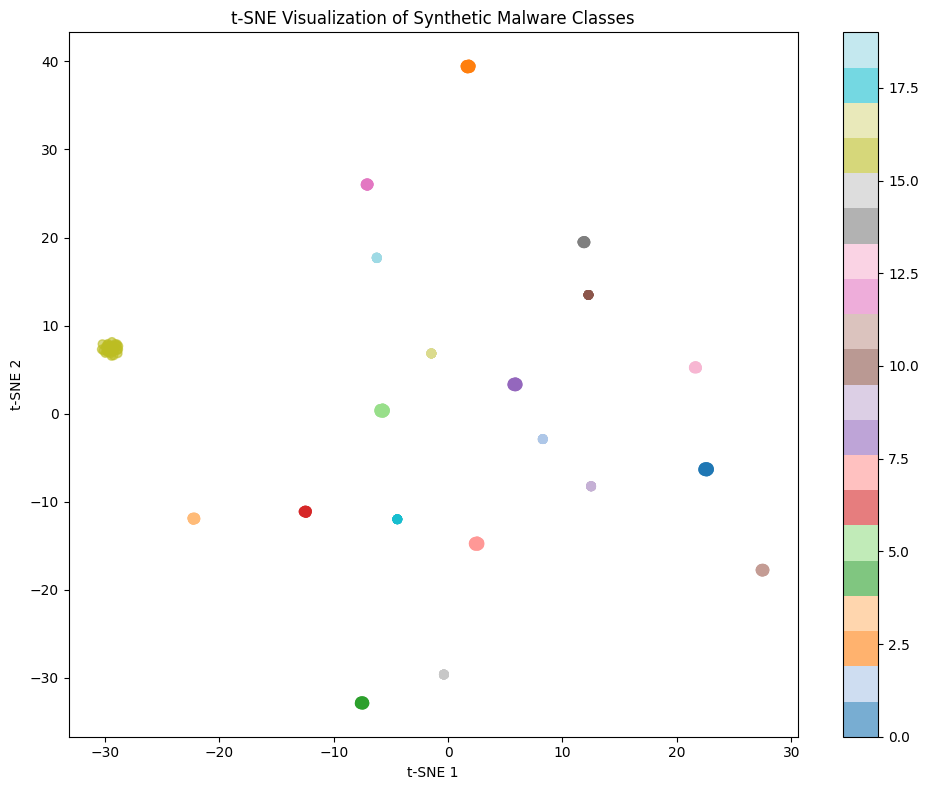

In [12]:
# Visualize data distribution using t-SNE
from sklearn.manifold import TSNE

# Sample subset for visualization
sample_indices = np.random.choice(len(data), 500, replace=False)
sample_data = data[sample_indices]
sample_labels = labels[sample_indices]

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(sample_data)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings[:, 0], embeddings[:, 1], 
                     c=sample_labels, cmap='tab20', alpha=0.6)
plt.colorbar(scatter)
plt.title("t-SNE Visualization of Synthetic Malware Classes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


## 3. Simple Feature Encoder

For demonstration, we'll use a simple MLP encoder. In practice, this would be replaced with a Vision Transformer for packet image features.


In [13]:
# Simple encoder for demonstration (replace with ViT in practice)
class SimpleEncoder(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, output_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

# Create encoder
encoder = SimpleEncoder(input_dim=256, hidden_dim=128, output_dim=64)
encoder.to(device)

# Test encoder
test_input = torch.randn(32, 256).to(device)
test_output = encoder(test_input)
print(f"Encoder output shape: {test_output.shape}")


Encoder output shape: torch.Size([32, 64])


## 4. Prototypical Networks Demonstration

Let's demonstrate how Prototypical Networks work for few-shot learning.


In [14]:
# Import our Prototypical Networks implementation
import sys
sys.path.append('..')
from src.few_shot.prototypical_net import PrototypicalNetwork

# Create Prototypical Network
proto_net = PrototypicalNetwork(encoder, distance_metric='euclidean')
proto_net.to(device)

# Demonstrate on a single episode
episode_sampler = EpisodeSampler(val_data, val_labels, n_way=5, k_shot=5, n_query=15)
episode = episode_sampler.sample_episode()

# Move to device
support_data = episode.support_data.to(device)
support_labels = episode.support_labels.to(device)
query_data = episode.query_data.to(device)
query_labels = episode.query_labels.to(device)

# Forward pass
with torch.no_grad():
    log_probs, predictions, prototypes = proto_net(support_data, support_labels, query_data)
    accuracy = (predictions == query_labels).float().mean()
    
print(f"Episode Details:")
print(f"  N-way: {episode.n_way}")
print(f"  K-shot: {episode.k_shot}")
print(f"  N-query: {episode.n_query}")
print(f"  Query Accuracy: {accuracy:.2%}")


Episode Details:
  N-way: 5
  K-shot: 5
  N-query: 15
  Query Accuracy: 100.00%


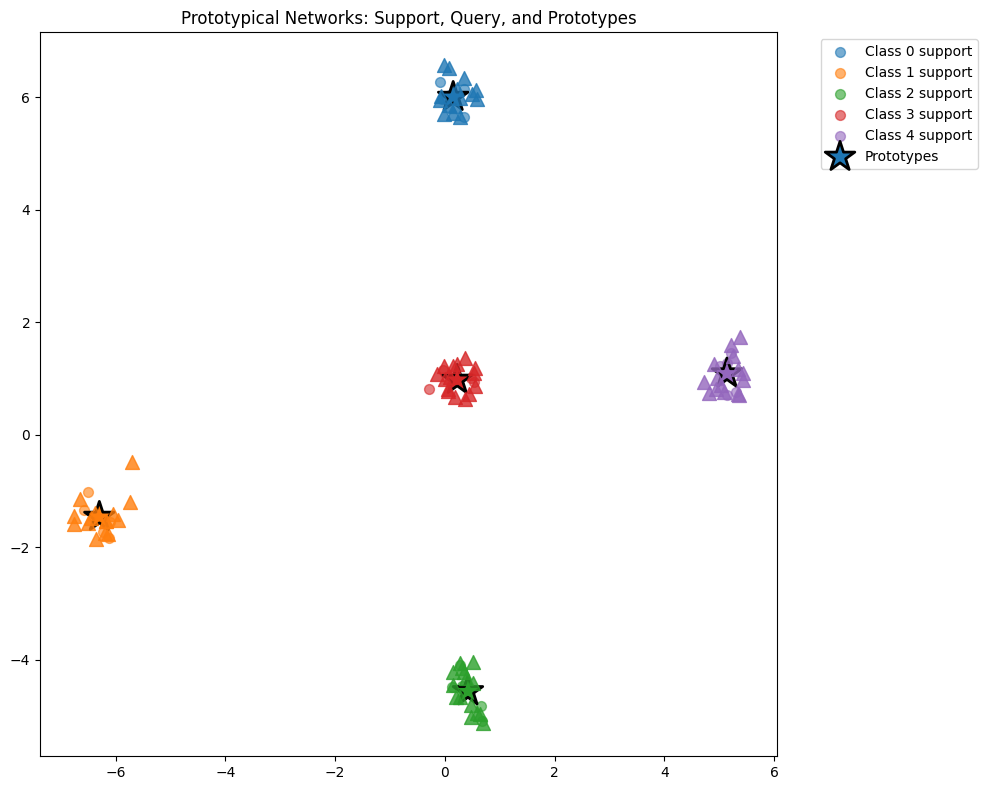

In [15]:
# Visualize prototypes and query predictions
def visualize_prototypes(support_features, support_labels, query_features, query_labels, 
                        prototypes, predictions):
    """Visualize prototypes and query predictions in 2D using t-SNE."""
    # Combine all features for t-SNE
    all_features = torch.cat([support_features, query_features, prototypes]).cpu().numpy()
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embeddings = tsne.fit_transform(all_features)
    
    # Split embeddings
    n_support = len(support_features)
    n_query = len(query_features)
    support_emb = embeddings[:n_support]
    query_emb = embeddings[n_support:n_support+n_query]
    proto_emb = embeddings[n_support+n_query:]
    
    # Plot
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10(np.arange(len(prototypes)))
    
    # Plot support points
    for i in range(len(prototypes)):
        mask = support_labels.cpu() == i
        plt.scatter(support_emb[mask, 0], support_emb[mask, 1], 
                   c=[colors[i]], marker='o', s=50, alpha=0.6, 
                   label=f'Class {i} support')
    
    # Plot prototypes
    plt.scatter(proto_emb[:, 0], proto_emb[:, 1], 
               c=colors, marker='*', s=500, edgecolor='black', 
               linewidth=2, label='Prototypes')
    
    # Plot query points
    for i in range(len(prototypes)):
        mask = query_labels.cpu() == i
        correct_mask = (query_labels.cpu() == predictions.cpu()) & mask
        incorrect_mask = (query_labels.cpu() != predictions.cpu()) & mask
        
        if correct_mask.any():
            plt.scatter(query_emb[correct_mask, 0], query_emb[correct_mask, 1], 
                       c=[colors[i]], marker='^', s=100, alpha=0.8)
        if incorrect_mask.any():
            plt.scatter(query_emb[incorrect_mask, 0], query_emb[incorrect_mask, 1], 
                       c=[colors[i]], marker='x', s=100, alpha=0.8)
    
    plt.title("Prototypical Networks: Support, Query, and Prototypes")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Extract features for visualization
with torch.no_grad():
    support_features = proto_net.encoder(support_data)
    query_features = proto_net.encoder(query_data)
    
visualize_prototypes(support_features, support_labels, query_features, 
                    query_labels, prototypes, predictions)


## 5. Evaluation Protocols

Let's evaluate performance across different few-shot scenarios.


In [16]:
def evaluate_few_shot(proto_net, data, labels, n_way, k_shot, n_query, num_episodes=100):
    """Evaluate few-shot performance over multiple episodes."""
    sampler = EpisodeSampler(data, labels, n_way, k_shot, n_query)
    
    accuracies = []
    losses = []
    
    for _ in range(num_episodes):
        episode = sampler.sample_episode()
        
        # Move to device
        support_data = episode.support_data.to(device)
        support_labels = episode.support_labels.to(device)
        query_data = episode.query_data.to(device)
        query_labels = episode.query_labels.to(device)
        
        # Forward pass
        with torch.no_grad():
            log_probs, predictions, _ = proto_net(support_data, support_labels, query_data)
            
            # Compute accuracy
            accuracy = (predictions == query_labels).float().mean().item()
            
            # Compute loss
            loss = F.cross_entropy(log_probs, query_labels).item()
            
        accuracies.append(accuracy)
        losses.append(loss)
    
    return {
        'mean_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'mean_loss': np.mean(losses),
        'std_loss': np.std(losses),
        'accuracies': accuracies
    }

# Evaluate different scenarios
# Note: Test set only has 5 classes, so n_way must be <= 5
scenarios = [
    (5, 1, 15),   # 5-way 1-shot
    (5, 5, 15),   # 5-way 5-shot
    (5, 10, 15),  # 5-way 10-shot
    (3, 5, 15),   # 3-way 5-shot
    (4, 5, 15),   # 4-way 5-shot (changed from 10-way)
]

results = {}
for n_way, k_shot, n_query in scenarios:
    print(f"\nEvaluating {n_way}-way {k_shot}-shot...")
    result = evaluate_few_shot(proto_net, test_data, test_labels, 
                              n_way, k_shot, n_query, num_episodes=100)
    results[f"{n_way}-way-{k_shot}-shot"] = result
    print(f"  Accuracy: {result['mean_accuracy']:.2%} ± {result['std_accuracy']:.2%}")
    print(f"  Loss: {result['mean_loss']:.3f} ± {result['std_loss']:.3f}")



Evaluating 5-way 1-shot...
  Accuracy: 100.00% ± 0.00%
  Loss: 0.054 ± 0.006

Evaluating 5-way 5-shot...
  Accuracy: 100.00% ± 0.00%
  Loss: 0.047 ± 0.002

Evaluating 5-way 10-shot...
  Accuracy: 100.00% ± 0.00%
  Loss: 0.046 ± 0.003

Evaluating 3-way 5-shot...
  Accuracy: 100.00% ± 0.00%
  Loss: 0.039 ± 0.011

Evaluating 4-way 5-shot...
  Accuracy: 100.00% ± 0.00%
  Loss: 0.042 ± 0.006


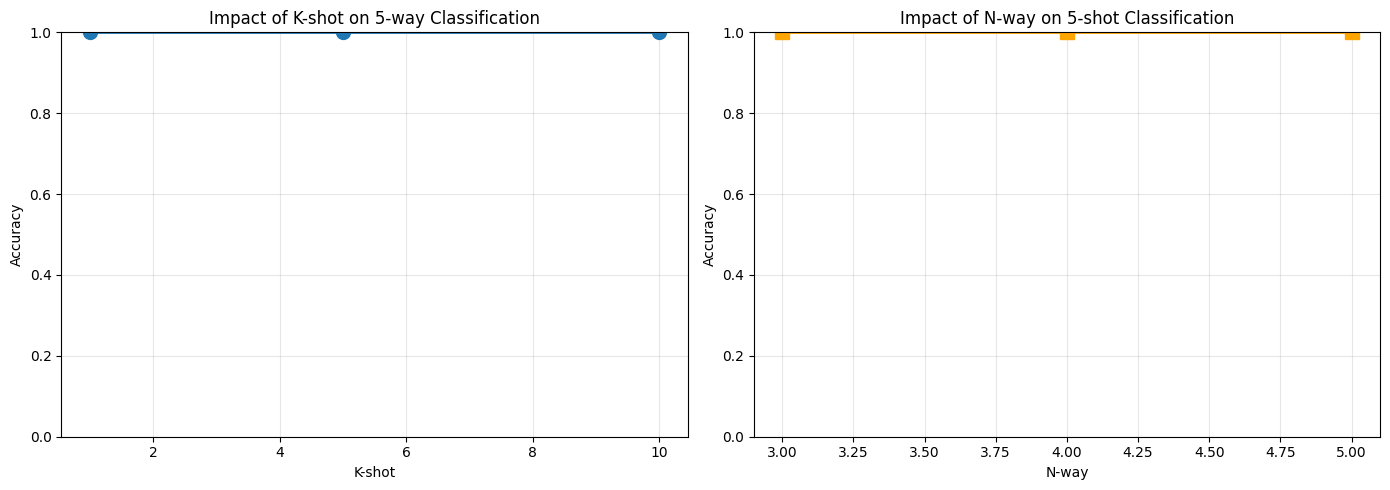

In [17]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Impact of K-shot
k_shot_results = [(1, results['5-way-1-shot']), 
                  (5, results['5-way-5-shot']), 
                  (10, results['5-way-10-shot'])]
k_values = [k for k, _ in k_shot_results]
accuracies = [r['mean_accuracy'] for _, r in k_shot_results]
stds = [r['std_accuracy'] for _, r in k_shot_results]

ax1.errorbar(k_values, accuracies, yerr=stds, marker='o', markersize=10, 
             linewidth=2, capsize=5)
ax1.set_xlabel('K-shot')
ax1.set_ylabel('Accuracy')
ax1.set_title('Impact of K-shot on 5-way Classification')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Impact of N-way
n_way_results = [(3, results['3-way-5-shot']), 
                 (4, results['4-way-5-shot']), 
                 (5, results['5-way-5-shot'])]
n_values = [n for n, _ in n_way_results]
accuracies = [r['mean_accuracy'] for _, r in n_way_results]
stds = [r['std_accuracy'] for _, r in n_way_results]

ax2.errorbar(n_values, accuracies, yerr=stds, marker='s', markersize=10, 
             linewidth=2, capsize=5, color='orange')
ax2.set_xlabel('N-way')
ax2.set_ylabel('Accuracy')
ax2.set_title('Impact of N-way on 5-shot Classification')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## 6. Learning Dynamics Visualization

Let's visualize how the accuracy distribution changes across episodes.


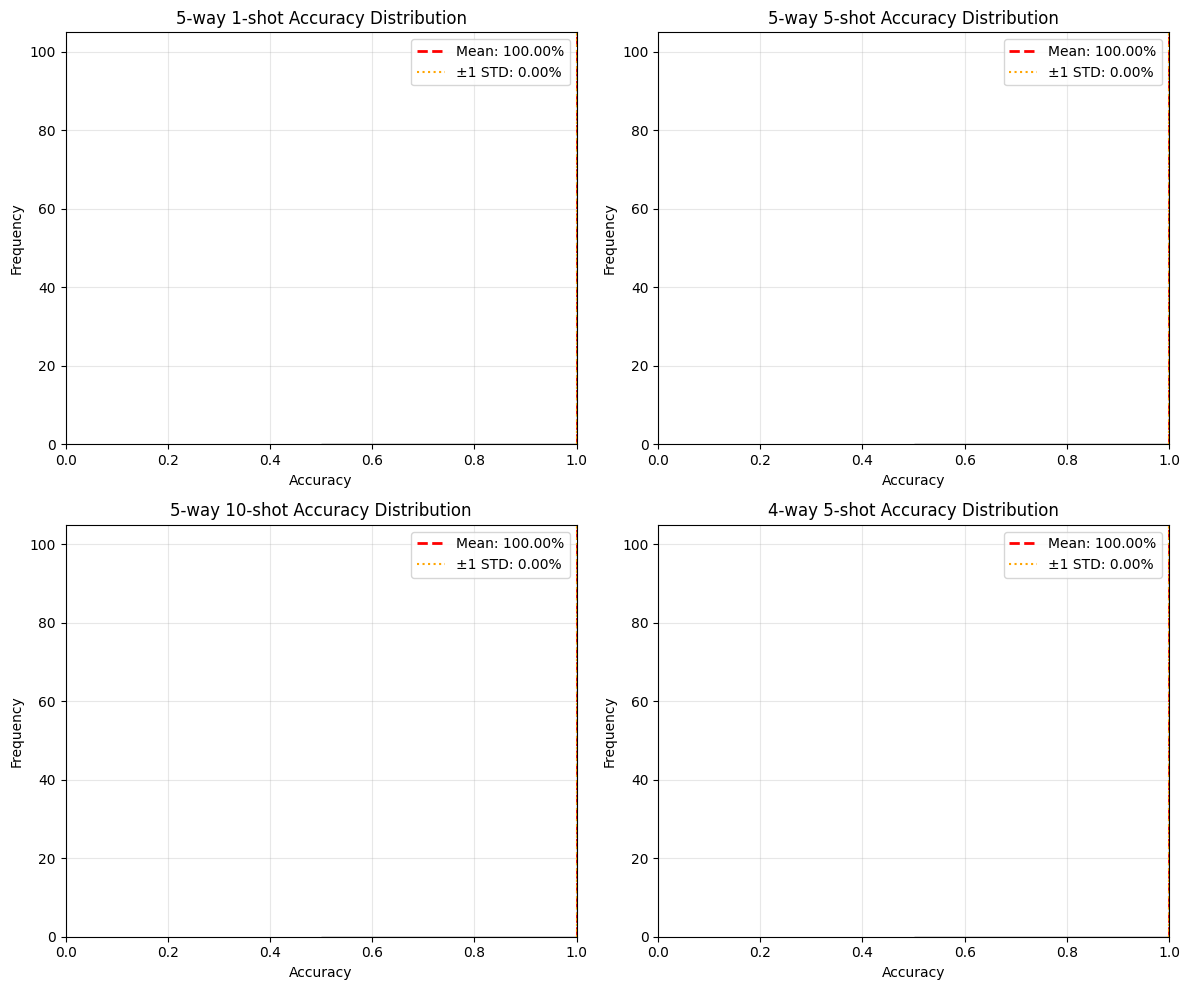

In [18]:
# Visualize accuracy distribution across episodes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

scenarios_to_plot = [
    ('5-way-1-shot', '5-way 1-shot'),
    ('5-way-5-shot', '5-way 5-shot'),
    ('5-way-10-shot', '5-way 10-shot'),
    ('4-way-5-shot', '4-way 5-shot')
]

for idx, (scenario_key, scenario_name) in enumerate(scenarios_to_plot):
    ax = axes[idx]
    accuracies = results[scenario_key]['accuracies']
    
    # Plot histogram
    ax.hist(accuracies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Add statistics
    mean_acc = results[scenario_key]['mean_accuracy']
    std_acc = results[scenario_key]['std_accuracy']
    
    ax.axvline(mean_acc, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_acc:.2%}')
    ax.axvline(mean_acc - std_acc, color='orange', linestyle=':', linewidth=1.5)
    ax.axvline(mean_acc + std_acc, color='orange', linestyle=':', linewidth=1.5, 
               label=f'±1 STD: {std_acc:.2%}')
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{scenario_name} Accuracy Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## 7. Summary and Key Insights

### Key Findings:
1. **K-shot Impact**: Performance improves significantly with more support examples
2. **N-way Impact**: Accuracy decreases as the number of classes increases
3. **Stability**: Higher K values lead to more stable performance (lower variance)

### Next Steps:
1. Implement MAML for gradient-based adaptation
2. Compare different distance metrics (cosine vs euclidean)
3. Test on real malware packet data
4. Implement novel malware detection system

### Implementation Notes:
- Prototypical Networks are simple and effective for few-shot learning
- The episodic training paradigm is crucial for meta-learning
- Feature quality from the encoder is critical for performance
